In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from src.load_data_BCICIV import load_all_subjects
from src.train_CNN import train_model_cv
import torch
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import mlflow

np.random.seed(42)
torch.manual_seed(42)


/home/alumno/Desktop/datos/a/Biosignal-ML-Analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# DATA LOAD

In [2]:
data_path = '../datasets/BCICIV_2a_gdf'

data_22 = load_all_subjects(data_path, channels_to_use='all')
data_22_multiband = load_all_subjects(data_path, use_multiband=True, bands=[(8, 12), (13, 30)], channels_to_use='all')
data_11 = load_all_subjects(data_path)
data_11_multiband = load_all_subjects(data_path, use_multiband=True, bands=[(8, 12), (13, 30)])

/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A01T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A02T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A08T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A09T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-l

In [3]:
subjects = data_22['subject_ids'] 

X_22 = data_22['X'] 
y_22 = data_22['y'] 

X_22_multiband = data_22_multiband['X'] 
y_22_multiband = data_22_multiband['y'] 

X_11 = data_11['X'] 
y_11 = data_11['y'] 

X_11_multiband = data_11_multiband['X'] 
y_11_multiband = data_11_multiband['y'] 

# ShallowConvNet

In [4]:
models = {
    'model': [],
    'accuracies': [],
    'name': []
}

model_type = 'shallow'

## Tests with 22 channels

### 22 channels (raw + normalization)

In [5]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=[], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('raw_22')

2026/03/30 08:53:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 1 | Subject A01 | Train Acc: 0.9123 | Test Acc: 0.7133


2026/03/30 08:53:34 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 08:53:59 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 08:55:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 2 | Subject A02 | Train Acc: 0.9278 | Test Acc: 0.6111


2026/03/30 08:55:00 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 08:55:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 08:56:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 08:56:07 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytor

...

Fold 8 | Subject A08 | Train Acc: 0.9330 | Test Acc: 0.6458


2026/03/30 09:01:12 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 09:01:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:02:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9539 | Test Acc: 0.4861


2026/03/30 09:02:14 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 09:02:18 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6222 ± 0.0599


### 22 channels + laplacian filter on C3 and C4

In [6]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=['laplacian'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22')

2026/03/30 09:03:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:03:16 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9522 | Test Acc: 0.7413


2026/03/30 09:03:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:04:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:04:22 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9574 | Test Acc: 0.5556


2026/03/30 09:04:27 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:05:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:05:30 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9739 | Test Acc: 0.6319


2026/03/30 09:10:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 09:10:48 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:11:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9696 | Test Acc: 0.5208


2026/03/30 09:11:46 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 09:11:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6168 ± 0.0602


### 22 channels - only mu band

In [7]:
model, test_subject_accuracies = train_model_cv(X_22_multiband, y_22_multiband, subjects, transforms=['laplacian', 'mu_band'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('mu_22')

2026/03/30 09:12:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:12:48 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9123 | Test Acc: 0.6853


2026/03/30 09:12:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:13:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:13:50 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9191 | Test Acc: 0.5486


2026/03/30 09:13:55 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:14:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:14:53 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9130 | Test Acc: 0.6528


2026/03/30 09:20:16 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 09:20:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:21:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9261 | Test Acc: 0.5347


2026/03/30 09:21:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 09:21:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5873 ± 0.0601


### 22 channels - mu + beta band

In [8]:
model, test_subject_accuracies = train_model_cv(X_22_multiband, y_22_multiband, subjects, transforms=['laplacian', 'multiband'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('multiband_22')

2026/03/30 09:22:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:22:31 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9844 | Test Acc: 0.6923


2026/03/30 09:22:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:23:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:23:46 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9809 | Test Acc: 0.5694


2026/03/30 09:23:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:25:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:25:02 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9817 | Test Acc: 0.5208


2026/03/30 09:31:03 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 09:31:07 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:32:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9817 | Test Acc: 0.5208


2026/03/30 09:32:13 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 09:32:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5959 ± 0.0530


## Tests with 11 channels

### 11 channels (raw + normalization)

In [9]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=[], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('raw_11')

2026/03/30 09:33:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:33:02 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8862 | Test Acc: 0.7762


2026/03/30 09:33:05 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:33:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:33:49 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9000 | Test Acc: 0.5486


2026/03/30 09:33:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:34:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:34:38 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9061 | Test Acc: 0.5833


2026/03/30 09:38:40 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 09:38:44 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:39:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9217 | Test Acc: 0.5347


2026/03/30 09:39:28 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 09:39:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6052 ± 0.0741


### 11 channels + laplacian filter on C3 and C4

In [10]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=['laplacian'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_11')

2026/03/30 09:40:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:40:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9548 | Test Acc: 0.7273


2026/03/30 09:40:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:41:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:41:06 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9487 | Test Acc: 0.6458


2026/03/30 09:41:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:41:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:41:54 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9461 | Test Acc: 0.6042


2026/03/30 09:46:03 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 09:46:07 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:46:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9626 | Test Acc: 0.5139


2026/03/30 09:46:52 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 09:46:56 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6183 ± 0.0719


### 11 channels - only mu band

In [11]:
model, test_subject_accuracies = train_model_cv(X_11_multiband, y_11_multiband, subjects, transforms=['laplacian', 'mu_band'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('mu_11')

2026/03/30 09:47:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:47:42 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8983 | Test Acc: 0.6643


2026/03/30 09:47:46 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:48:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:48:30 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9078 | Test Acc: 0.5972


2026/03/30 09:48:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:49:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:49:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.8922 | Test Acc: 0.6250


2026/03/30 09:53:34 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 09:53:38 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:54:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.8957 | Test Acc: 0.5417


2026/03/30 09:54:26 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 09:54:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6128 ± 0.0469


### 11 channels - mu + beta band

In [12]:
model, test_subject_accuracies = train_model_cv(X_11_multiband, y_11_multiband, subjects, transforms=['laplacian', 'multiband'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('multiband_11')

2026/03/30 09:55:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:55:35 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9618 | Test Acc: 0.6573


2026/03/30 09:55:39 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:56:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:56:46 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9748 | Test Acc: 0.6389


2026/03/30 09:56:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 09:57:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 09:57:58 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9826 | Test Acc: 0.5278


2026/03/30 10:03:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 10:03:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 10:04:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9817 | Test Acc: 0.5000


2026/03/30 10:04:24 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 10:04:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6090 ± 0.0768


## Data Augmentation

### 22 channels + laplace + data augmentation

In [13]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=['laplacian'], model_type=model_type, epochs=200, lr=0.0003, patience=20, augment=True)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22_aug')

Early stopping en epoch 183. Best train loss: 0.3339


2026/03/30 10:06:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 10:06:30 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8262 | Test Acc: 0.7203


2026/03/30 10:06:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                                            

Early stopping en epoch 130. Best train loss: 0.3531


...

Early stopping en epoch 128. Best train loss: 0.3429


2026/03/30 10:22:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 9 | Subject A09 | Train Acc: 0.8374 | Test Acc: 0.4722


2026/03/30 10:22:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 10:22:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6315 ± 0.0704


### 11 channels + laplace + data augmentation

In [14]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=['laplacian'], model_type=model_type, epochs=200, lr=0.0003, patience=20, augment=True)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_11_aug')

Early stopping en epoch 118. Best train loss: 0.4089


2026/03/30 10:23:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 1 | Subject A01 | Train Acc: 0.7932 | Test Acc: 0.6643


2026/03/30 10:23:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 10:23:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                                            

Early stopping en epoch 171. Best train loss: 0.3666


...

Early stopping en epoch 123. Best train loss: 0.3799


2026/03/30 10:34:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 9 | Subject A09 | Train Acc: 0.8078 | Test Acc: 0.5139


2026/03/30 10:34:42 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 10:34:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6136 ± 0.0635


## Visualization

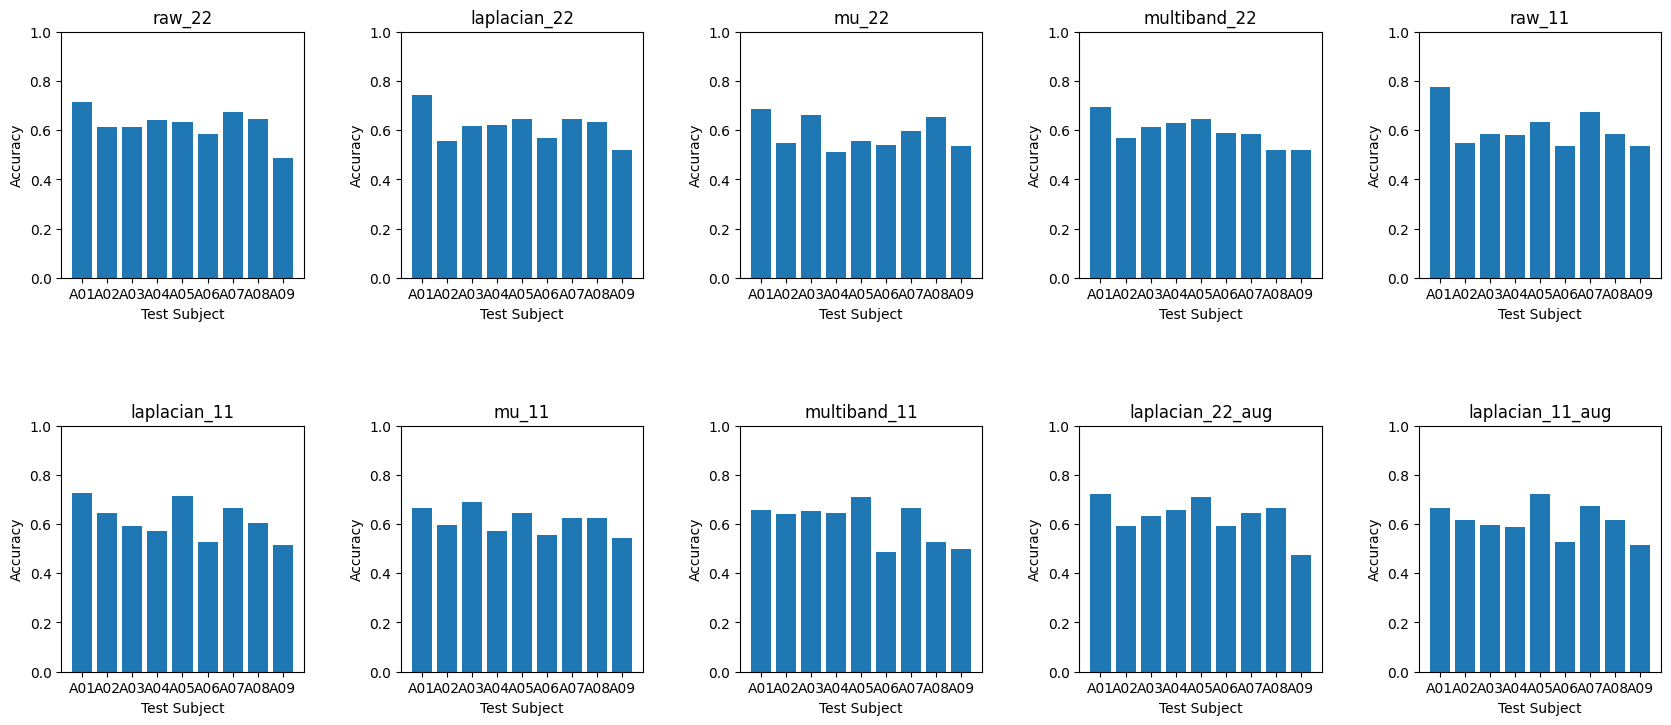

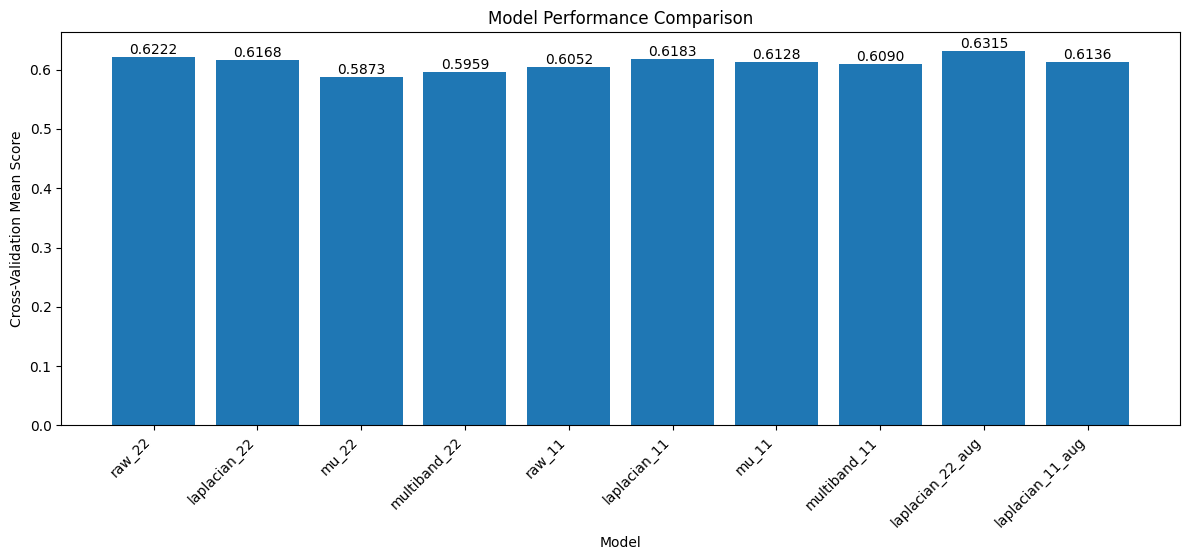

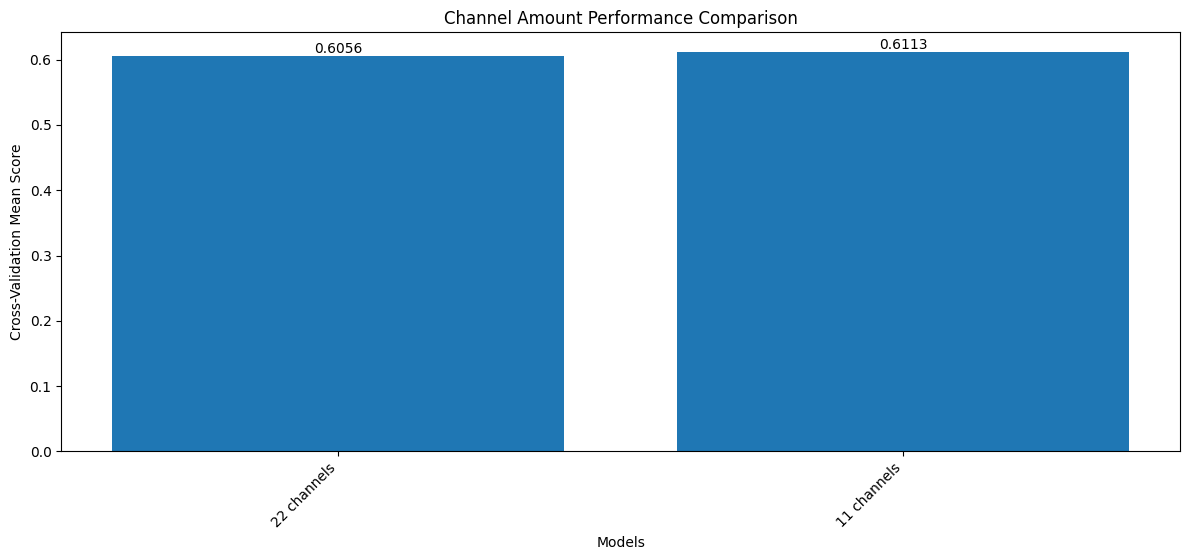

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, (name, accuracies) in enumerate(zip(models['name'], models['accuracies'])):
    ax = axes[i // 5, i % 5]
    ax.bar(np.unique(subjects), accuracies)
    ax.set_title(name)
    ax.set_xlabel('Test Subject')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.6)



accs = [] 

for acc in models['accuracies']:
    accs.append(np.mean(acc))

plt.figure(figsize=(12, 6))
bars = plt.bar(models['name'], accs)
plt.xlabel('Model')
plt.ylabel('Cross-Validation Mean Score')
plt.title('Model Performance Comparison')
plt.bar_label(bars, fmt="%.4f")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95],)


acc_11_ch = np.mean(accs[4:8])
acc_22_ch = np.mean(accs[:4])

plt.figure(figsize=(12, 6))
bars = plt.bar(['22 channels', '11 channels'], [acc_22_ch, acc_11_ch])
plt.xlabel('Models')
plt.ylabel('Cross-Validation Mean Score')
plt.title('Channel Amount Performance Comparison')
plt.bar_label(bars, fmt="%.4f")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95],)

# DeepConvNet

In [16]:
models = {
    'model': [],
    'accuracies': [],
    'name': []
}

model_type = 'deep'

## Tests with 22 channels

### 22 channels (raw + normalization)

In [17]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=[], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('raw_22')

2026/03/30 10:35:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 10:35:54 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9852 | Test Acc: 0.5664


2026/03/30 10:35:58 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 10:37:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 10:37:03 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9878 | Test Acc: 0.5694


2026/03/30 10:37:07 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 10:38:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


...

Fold 8 | Subject A08 | Train Acc: 0.9852 | Test Acc: 0.6458


2026/03/30 10:43:58 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 10:44:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 10:45:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9861 | Test Acc: 0.5347


2026/03/30 10:45:08 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 10:45:12 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5549 ± 0.0365


### 22 channels + laplacian filter on C3 and C4

In [18]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=['laplacian'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22')

2026/03/30 10:46:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 10:46:16 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9878 | Test Acc: 0.5455


2026/03/30 10:46:21 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 10:47:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 10:47:26 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9870 | Test Acc: 0.5486


2026/03/30 10:47:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 10:48:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 10:48:38 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9861 | Test Acc: 0.6111


2026/03/30 10:54:55 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 10:54:59 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 10:56:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9887 | Test Acc: 0.5417


2026/03/30 10:56:05 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 10:56:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5595 ± 0.0262


### 22 channels - only mu band

In [19]:
model, test_subject_accuracies = train_model_cv(X_22_multiband, y_22_multiband, subjects, transforms=['laplacian', 'mu_band'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('mu_22')

2026/03/30 10:57:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 10:57:16 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9870 | Test Acc: 0.6294


2026/03/30 10:57:21 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 10:58:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 10:58:31 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9878 | Test Acc: 0.4722


2026/03/30 10:58:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 10:59:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/30 10:59:45 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 4 | Subject A04 | Train Acc: 0.9939 | Test Acc: 0.5594


2026/03/30 11:01:02 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 11:01:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/30 11:02:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 5 | Subject A05 | Train Acc: 0.9870 | Test Acc: 0.5417


2026/03/30 11:02:12 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/30 11:02:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


KeyboardInterrupt: 

### 22 channels - mu + beta band

In [ ]:
model, test_subject_accuracies = train_model_cv(X_22_multiband, y_22_multiband, subjects, transforms=['laplacian', 'multiband'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('multiband_22')

2026/03/26 12:05:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/26 12:05:36 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9870 | Test Acc: 0.5175


2026/03/26 12:05:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 12:06:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/26 12:06:42 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9870 | Test Acc: 0.5347


2026/03/26 12:06:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 12:07:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/26 12:07:50 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9904 | Test Acc: 0.6111


2026/03/26 12:13:22 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 12:13:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 12:14:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9913 | Test Acc: 0.5417


2026/03/26 12:14:28 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 12:14:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5549 ± 0.0345


## Tests with 11 channels

### 11 channels (raw + normalization)

In [ ]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=[], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('raw_11')

2026/03/26 12:15:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/26 12:15:22 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9835 | Test Acc: 0.5524


2026/03/26 12:15:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 12:16:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 2 | Subject A02 | Train Acc: 0.9922 | Test Acc: 0.5278


2026/03/26 12:16:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 12:16:27 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 12:17:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


...

Fold 8 | Subject A08 | Train Acc: 0.9887 | Test Acc: 0.5486


2026/03/26 12:21:56 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 12:22:00 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 12:22:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9843 | Test Acc: 0.4931


2026/03/26 12:22:50 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 12:22:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5510 ± 0.0257


### 11 channels + laplacian filter on C3 and C4

In [ ]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=['laplacian'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_11')

2026/03/26 12:23:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/26 12:23:47 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9913 | Test Acc: 0.6154


2026/03/26 12:23:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 12:24:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/26 12:24:42 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9904 | Test Acc: 0.5625


2026/03/26 12:24:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 12:25:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


...

Fold 8 | Subject A08 | Train Acc: 0.9887 | Test Acc: 0.5833


2026/03/26 12:30:10 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 12:30:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Fold 9 | Subject A09 | Train Acc: 0.9896 | Test Acc: 0.5139


2026/03/26 12:31:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/26 12:31:07 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 12:31:11 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5819 ± 0.0298


### 11 channels - only mu band

In [ ]:
model, test_subject_accuracies = train_model_cv(X_11_multiband, y_11_multiband, subjects, transforms=['laplacian', 'mu_band'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('mu_11')

2026/03/26 12:32:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/26 12:32:04 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9904 | Test Acc: 0.6364


2026/03/26 12:32:08 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 12:32:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/26 12:32:55 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9904 | Test Acc: 0.5208


2026/03/26 12:32:59 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 12:33:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/26 12:33:47 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9922 | Test Acc: 0.5278


2026/03/26 12:38:12 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 12:38:16 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 12:39:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9913 | Test Acc: 0.5625


2026/03/26 12:39:06 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 12:39:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5773 ± 0.0469


### 11 channels - mu + beta band

In [ ]:
model, test_subject_accuracies = train_model_cv(X_11_multiband, y_11_multiband, subjects, transforms=['laplacian', 'multiband'], model_type=model_type, epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('multiband_11')

2026/03/26 12:40:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/26 12:40:08 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9896 | Test Acc: 0.6853


2026/03/26 12:40:12 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 12:41:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/26 12:41:11 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9896 | Test Acc: 0.5417


2026/03/26 12:41:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 12:42:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/26 12:42:13 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9896 | Test Acc: 0.6042


2026/03/26 12:47:30 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 12:47:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 12:48:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9922 | Test Acc: 0.5417


2026/03/26 12:48:35 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 12:48:39 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5889 ± 0.0502


## Data Augmentation

### 22 channels + laplace + data augmentation

In [ ]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=['laplacian'], model_type=model_type, epochs=200, lr=0.0003, patience=20, augment=True)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22_aug')

Early stopping en epoch 183. Best train loss: 0.2670


2026/03/26 12:50:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/26 12:50:30 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8575 | Test Acc: 0.5524


2026/03/26 12:50:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                                            

Early stopping en epoch 153. Best train loss: 0.2766


...

Early stopping en epoch 138. Best train loss: 0.2904


2026/03/26 13:05:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 9 | Subject A09 | Train Acc: 0.8365 | Test Acc: 0.5069


2026/03/26 13:05:26 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 13:05:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5371 ± 0.0352


### 11 channels + laplace + data augmentation

In [ ]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=['laplacian'], model_type=model_type, epochs=200, lr=0.0003, patience=20, augment=True)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_11_aug')

Early stopping en epoch 146. Best train loss: 0.2900


2026/03/26 13:06:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/26 13:06:43 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8558 | Test Acc: 0.5245


2026/03/26 13:06:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                                            

Early stopping en epoch 182. Best train loss: 0.2838


...

Early stopping en epoch 194. Best train loss: 0.2730


2026/03/26 13:18:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 9 | Subject A09 | Train Acc: 0.8548 | Test Acc: 0.5417


2026/03/26 13:18:34 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 13:18:38 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5672 ± 0.0488


## Visualization

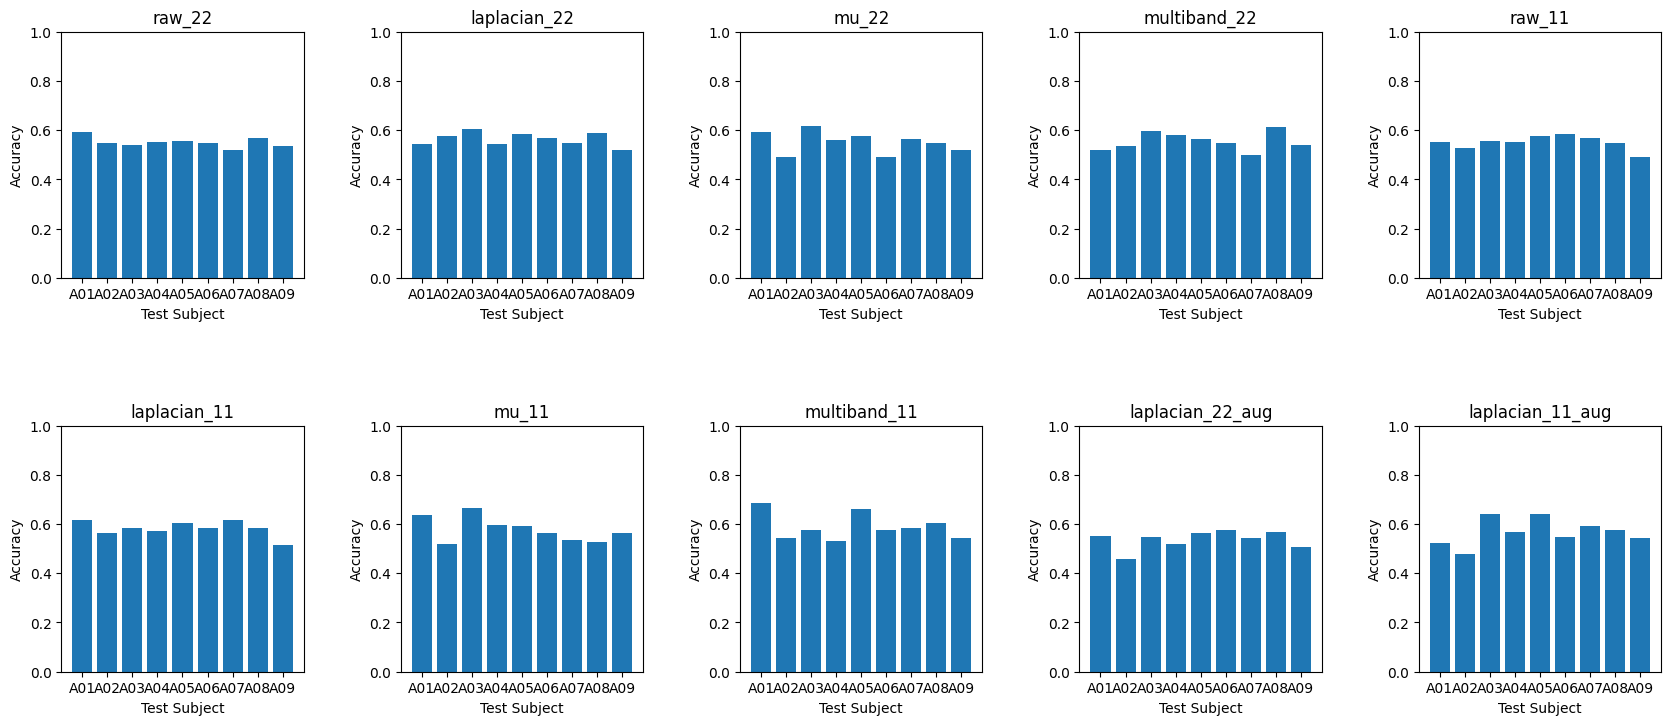

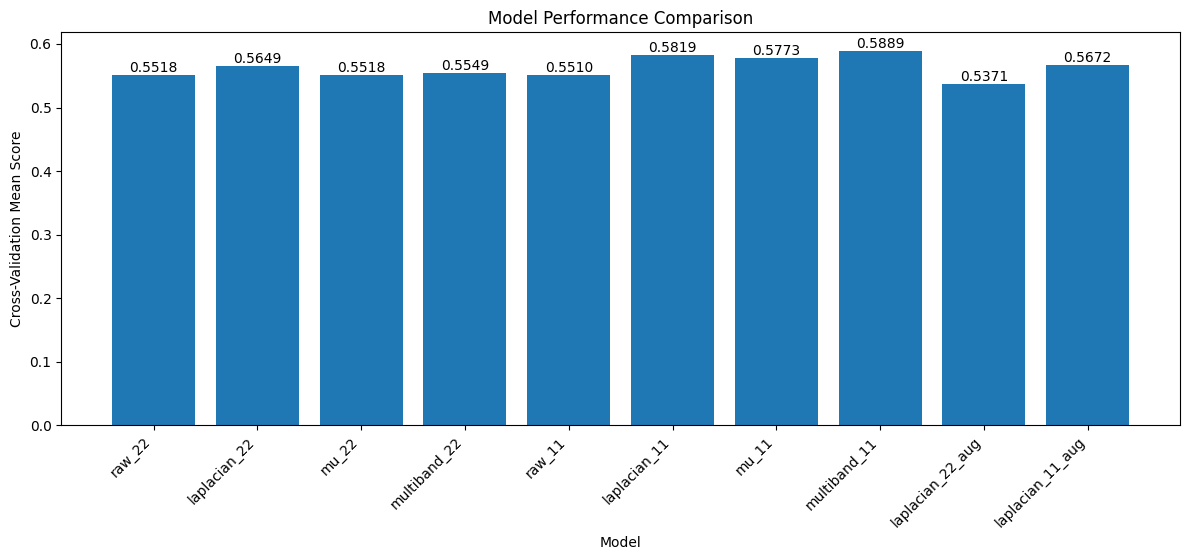

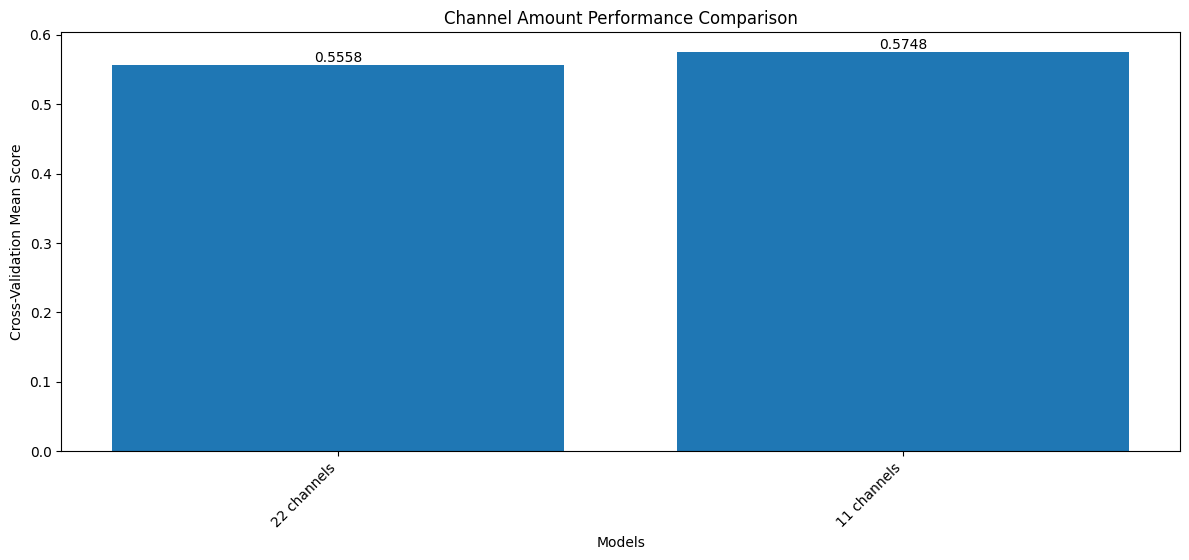

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, (name, accuracies) in enumerate(zip(models['name'], models['accuracies'])):
    ax = axes[i // 5, i % 5]
    ax.bar(np.unique(subjects), accuracies)
    ax.set_title(name)
    ax.set_xlabel('Test Subject')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.6)



accs = [] 

for acc in models['accuracies']:
    accs.append(np.mean(acc))

plt.figure(figsize=(12, 6))
bars = plt.bar(models['name'], accs)
plt.xlabel('Model')
plt.ylabel('Cross-Validation Mean Score')
plt.title('Model Performance Comparison')
plt.bar_label(bars, fmt="%.4f")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95],)

acc_11_ch = np.mean(accs[4:8])
acc_22_ch = np.mean(accs[:4])

plt.figure(figsize=(12, 6))
bars = plt.bar(['22 channels', '11 channels'], [acc_22_ch, acc_11_ch])
plt.xlabel('Models')
plt.ylabel('Cross-Validation Mean Score')
plt.title('Channel Amount Performance Comparison')
plt.bar_label(bars, fmt="%.4f")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95],)